# DistilBERT: a distilled version of BERT

Sanh, Debut, Chaumond, Wolf (Hugging Face) — EMC² @ NeurIPS 2019. [Paper PDF](DistillBERT.pdf)

**The idea:** train a small **student** to reproduce a large **teacher**'s full output
distribution, not just its hard predictions. The teacher's "near-zero" probabilities on wrong
classes still carry information — how plausible each mistake is — that one-hot labels discard.

**Distillation loss**, with a softmax temperature `T` applied to both models (T=1 at inference):

$$L_{ce} = -\sum_i t_i \log(s_i), \quad p_i = \frac{\exp(z_i/T)}{\sum_j \exp(z_j/T)}$$

**Triple loss** (paper's Section 2-3): a weighted sum of the distillation loss, a supervised loss
against gold labels, and a cosine-embedding loss aligning student/teacher hidden state directions.

**Student architecture:** same general shape as BERT, half the transformer layers, no token-type
embeddings. **Initialization:** student layer `i` copies teacher layer `2*i` — taking advantage of
the shared hidden size between teacher and student.

**Scope note:** the paper's actual headline result distills *during general-purpose MLM
pretraining* on Wikipedia + BookCorpus (90 GPU-hours on 8×V100). That's not reproducible locally, so
this notebook scopes down to **task-specific distillation**: an off-the-shelf fine-tuned BERT is the
frozen teacher, and the student is trained directly on IMDb sentiment classification, replacing the
paper's MLM loss term with a supervised classification loss. See `design.md` for the full rationale.
Three variants isolate each loss term's contribution, mirroring the paper's own ablation (Table 4):

1. **baseline** — supervised task loss only, no distillation signal.
2. **distill** — distillation loss + task loss.
3. **triple** — distillation loss + task loss + cosine loss (paper's full recipe, adapted).


In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from datasets import load_dataset
from transformers import AutoModelForSequenceClassification, AutoTokenizer

from model import LossWeights, build_student, cosine_loss, distillation_loss, init_student_from_teacher
from train import evaluate, predict, train_loop

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)
TEACHER_NAME = "textattack/bert-base-uncased-imdb"
MAX_LENGTH = 256
BATCH_SIZE = 16
NUM_EPOCHS = 2

torch.manual_seed(0)


Using device: mps


## Teacher

An off-the-shelf BERT-base already fine-tuned on IMDb (`textattack/bert-base-uncased-imdb`),
frozen — this notebook never fine-tunes it, only distills from it.


In [2]:
tokenizer = AutoTokenizer.from_pretrained(TEACHER_NAME)
teacher = AutoModelForSequenceClassification.from_pretrained(TEACHER_NAME).to(device)
teacher.eval()
for p in teacher.parameters():
    p.requires_grad_(False)

teacher_params = sum(p.numel() for p in teacher.parameters())
print(f"Teacher: {teacher.config.num_hidden_layers} layers, {teacher_params:,} parameters")


Teacher: 12 layers, 109,483,778 parameters


## IMDb dataset

Full train/test splits (25k / 25k), reviews truncated to 256 tokens. A 1,000-example slice of the
test set is used for cheap per-epoch tracking during training; the full 25k test set is used once
per model for the headline accuracy/F1 numbers.


In [3]:
raw = load_dataset("stanfordnlp/imdb")


def tokenize(batch):
    return tokenizer(
        batch["text"], truncation=True, max_length=MAX_LENGTH, padding="max_length"
    )


tokenized = raw.map(tokenize, batched=True, remove_columns=["text"])
tokenized = tokenized.rename_column("label", "labels")
tokenized.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

train_loader = torch.utils.data.DataLoader(tokenized["train"], batch_size=BATCH_SIZE, shuffle=True)
test_loader_full = torch.utils.data.DataLoader(tokenized["test"], batch_size=BATCH_SIZE)
test_loader_quick = torch.utils.data.DataLoader(
    tokenized["test"].select(range(1000)), batch_size=BATCH_SIZE
)

print(f"Train: {len(tokenized['train'])}, Test: {len(tokenized['test'])}")


Train: 25000, Test: 25000


In [4]:
sanity_student = build_student(teacher, num_student_layers=6).to(device)
init_student_from_teacher(sanity_student, teacher)
assert torch.equal(
    sanity_student.bert.encoder.layer[0].attention.self.query.weight,
    teacher.bert.encoder.layer[0].attention.self.query.weight,
)
assert torch.equal(
    sanity_student.bert.encoder.layer[5].attention.self.query.weight,
    teacher.bert.encoder.layer[10].attention.self.query.weight,
)
student_params = sum(p.numel() for p in sanity_student.parameters())
print(
    f"Student: {sanity_student.config.num_hidden_layers} layers, {student_params:,} parameters "
    f"({student_params / teacher_params:.1%} of teacher)"
)
del sanity_student


Student: 6 layers, 66,955,778 parameters (61.2% of teacher)


## Training three variants

Same architecture and teacher-initialization every time — only the active loss terms differ. Each
variant trains a fresh student, evaluates on the full test set at the end, and persists its
checkpoint + per-step metrics under `results/`.


In [5]:
def run_variant(name: str, use_teacher: bool, weights: LossWeights):
    torch.manual_seed(0)
    student = build_student(teacher, num_student_layers=6).to(device)
    init_student_from_teacher(student, teacher)
    optimizer = torch.optim.AdamW(student.parameters(), lr=5e-5)

    variant_teacher = teacher if use_teacher else None
    history = train_loop(
        student,
        variant_teacher,
        train_loader,
        test_loader_quick,
        optimizer,
        weights,
        device=device,
        num_epochs=NUM_EPOCHS,
        results_dir=RESULTS_DIR,
        run_name=name,
        log_every=50,
    )

    start = time.perf_counter()
    final_metrics = evaluate(student, test_loader_full, device)
    inference_time = time.perf_counter() - start

    del student
    return {**history, "final_metrics": final_metrics, "inference_time": inference_time}


variants = {
    "baseline": {"use_teacher": False, "weights": LossWeights()},
    "distill": {"use_teacher": True, "weights": LossWeights(alpha_cos=0.0)},
    "triple": {"use_teacher": True, "weights": LossWeights()},
}

results = {}
for name, cfg in variants.items():
    print(f"\n=== Training variant: {name} ===")
    results[name] = run_variant(name, cfg["use_teacher"], cfg["weights"])
    print(f"{name} final metrics: {results[name]['final_metrics']}")



=== Training variant: baseline ===


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


baseline final metrics: {'accuracy': 0.9003599882125854, 'f1': 0.9024476209124731, 'loss': 0.2508524954319}

=== Training variant: distill ===


...

distill final metrics: {'accuracy': 0.9027600288391113, 'f1': 0.9021612267074496, 'loss': 0.2983241081237793}

=== Training variant: triple ===


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


triple final metrics: {'accuracy': 0.8998000025749207, 'f1': 0.9035536903707696, 'loss': 0.3223321735858917}


In [6]:
start = time.perf_counter()
teacher_metrics = evaluate(teacher, test_loader_full, device)
teacher_inference_time = time.perf_counter() - start
print(f"Teacher final metrics: {teacher_metrics}, inference time: {teacher_inference_time:.1f}s")


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


Teacher final metrics: {'accuracy': 0.9192399978637695, 'f1': 0.9183945677215958, 'loss': 0.3994584381580353}, inference time: 394.6s


## Results

Parameter count, accuracy/F1, and inference time, teacher vs. each student variant.


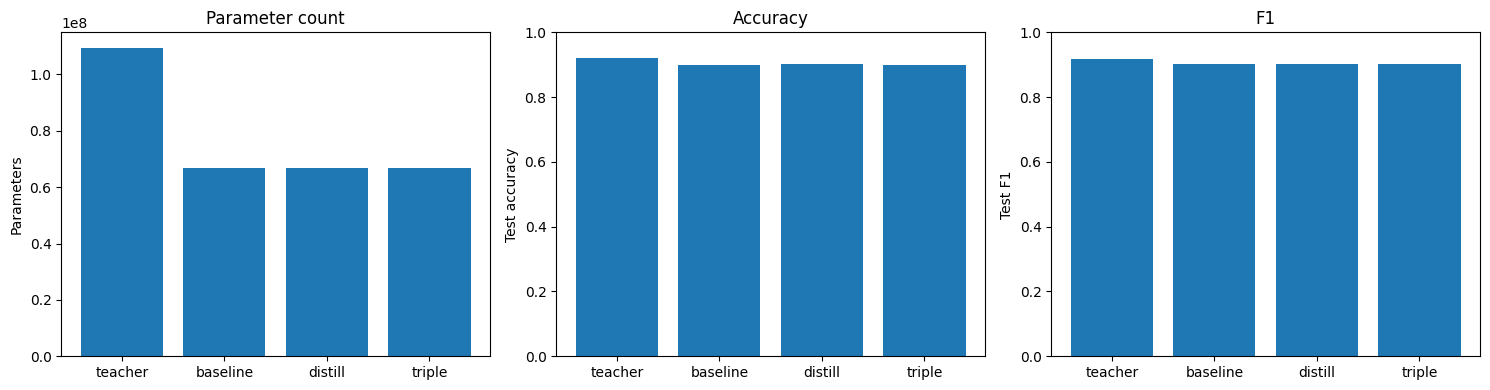

In [7]:
labels_order = ["teacher", "baseline", "distill", "triple"]
param_counts = [teacher_params] + [
    sum(p.numel() for p in build_student(teacher, num_student_layers=6).parameters())
] * 3
accuracies = [teacher_metrics["accuracy"]] + [results[n]["final_metrics"]["accuracy"] for n in variants]
f1s = [teacher_metrics["f1"]] + [results[n]["final_metrics"]["f1"] for n in variants]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].bar(labels_order, param_counts)
axes[0].set_ylabel("Parameters")
axes[0].set_title("Parameter count")

axes[1].bar(labels_order, accuracies)
axes[1].set_ylabel("Test accuracy")
axes[1].set_title("Accuracy")
axes[1].set_ylim(0, 1)

axes[2].bar(labels_order, f1s)
axes[2].set_ylabel("Test F1")
axes[2].set_title("F1")
axes[2].set_ylim(0, 1)
plt.tight_layout()
plt.show()


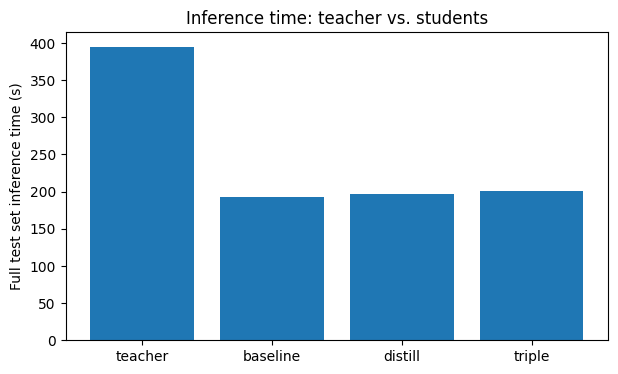

In [8]:
inference_times = [teacher_inference_time] + [results[n]["inference_time"] for n in variants]
plt.figure(figsize=(7, 4))
plt.bar(labels_order, inference_times)
plt.ylabel("Full test set inference time (s)")
plt.title("Inference time: teacher vs. students")
plt.show()


## Training curves and teacher/student agreement

Total training loss per variant, the triple-loss variant's individual loss components, and how
closely each student's predicted probability distribution matches the teacher's on the test set
(lower KL divergence = closer match, beyond just matching hard predictions).


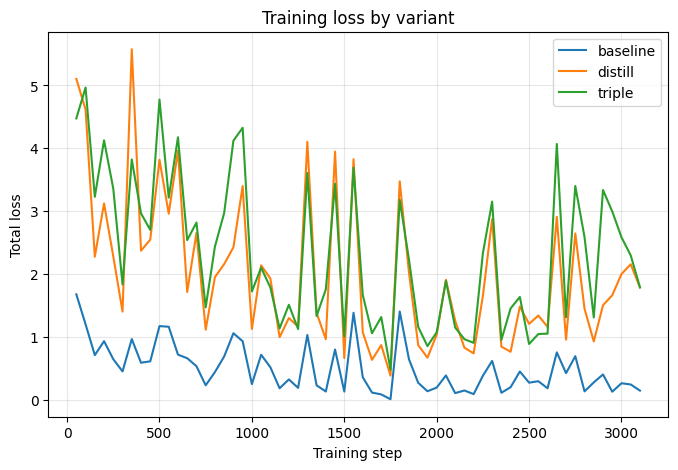

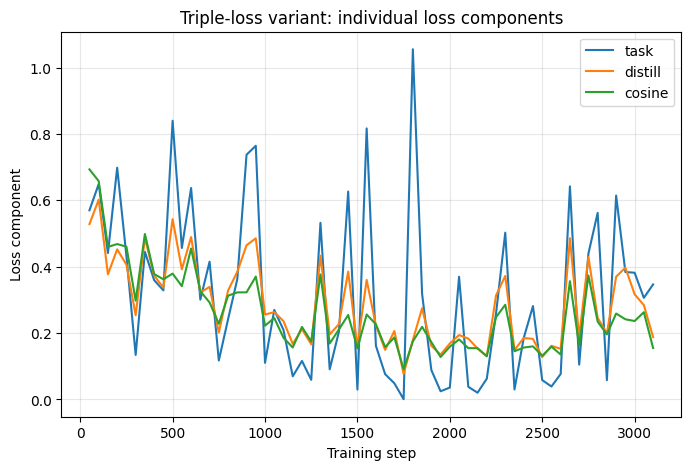

In [9]:
plt.figure(figsize=(8, 5))
for name in variants:
    steps = [m["step"] for m in results[name]["step_metrics"]]
    losses = [m["loss"] for m in results[name]["step_metrics"]]
    plt.plot(steps, losses, label=name)
plt.xlabel("Training step")
plt.ylabel("Total loss")
plt.title("Training loss by variant")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

triple_steps = [m["step"] for m in results["triple"]["step_metrics"]]
plt.figure(figsize=(8, 5))
plt.plot(triple_steps, [m["task_loss"] for m in results["triple"]["step_metrics"]], label="task")
plt.plot(triple_steps, [m["distill_loss"] for m in results["triple"]["step_metrics"]], label="distill")
plt.plot(triple_steps, [m["cos_loss"] for m in results["triple"]["step_metrics"]], label="cosine")
plt.xlabel("Training step")
plt.ylabel("Loss component")
plt.title("Triple-loss variant: individual loss components")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


Variant     KL(student||teacher)    Argmax agreement    
baseline    0.2271                  0.884               
distill     0.1966                  0.930               
triple      0.2481                  0.897               


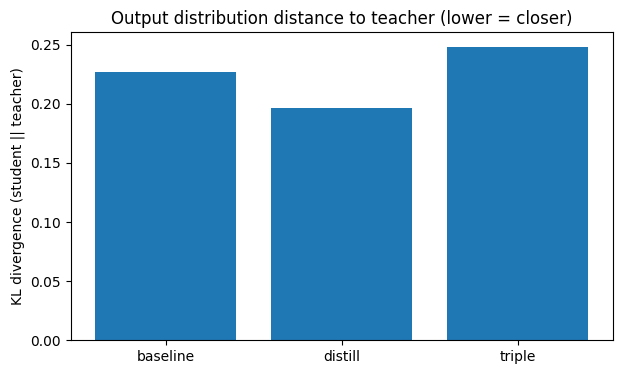

In [10]:
teacher_probs, _ = predict(teacher, test_loader_quick, device)

agreement_rows = []
for name in variants:
    student = build_student(teacher, num_student_layers=6).to(device)
    student.load_state_dict(torch.load(RESULTS_DIR / f"{name}.pt", map_location=device))
    student_probs, _ = predict(student, test_loader_quick, device)
    kl = F.kl_div(torch.log(student_probs.clamp_min(1e-12)), teacher_probs, reduction="batchmean")
    agreement = (student_probs.argmax(dim=-1) == teacher_probs.argmax(dim=-1)).float().mean()
    agreement_rows.append((name, kl.item(), agreement.item()))
    del student

print(f"{'Variant':<12}{'KL(student||teacher)':<24}{'Argmax agreement':<20}")
for name, kl, agreement in agreement_rows:
    print(f"{name:<12}{kl:<24.4f}{agreement:<20.3f}")

plt.figure(figsize=(7, 4))
plt.bar([r[0] for r in agreement_rows], [r[1] for r in agreement_rows])
plt.ylabel("KL divergence (student || teacher)")
plt.title("Output distribution distance to teacher (lower = closer)")
plt.show()


## Qualitative examples

A handful of fixed test reviews with the teacher's and each variant's predicted probability of
"positive."


In [11]:
sample_indices = [0, 1, 2, 3, 4]
sample_texts = [raw["test"][i]["text"][:200] for i in sample_indices]
sample_batch = {
    "input_ids": tokenized["test"][sample_indices]["input_ids"].to(device),
    "attention_mask": tokenized["test"][sample_indices]["attention_mask"].to(device),
}

with torch.no_grad():
    teacher_sample_probs = F.softmax(teacher(**sample_batch).logits, dim=-1)[:, 1]

student_sample_probs = {}
for name in variants:
    student = build_student(teacher, num_student_layers=6).to(device)
    student.load_state_dict(torch.load(RESULTS_DIR / f"{name}.pt", map_location=device))
    student.eval()
    with torch.no_grad():
        student_sample_probs[name] = F.softmax(student(**sample_batch).logits, dim=-1)[:, 1]
    del student

for i, text in enumerate(sample_texts):
    print(f"Review: {text}...")
    print(f"  teacher P(positive)={teacher_sample_probs[i]:.3f}", end="  ")
    for name in variants:
        print(f"{name}={student_sample_probs[name][i]:.3f}", end="  ")
    print("\n")


Review: I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-appreciated and misunderstood. I tried to like this, I really did, but it is to good TV sci-fi as Bab...
  teacher P(positive)=0.000  baseline=0.017  distill=0.001  triple=0.003  

Review: Worth the entertainment value of a rental, especially if you like action movies. This one features the usual car chases, fights with the great Van Damme kick style, shooting battles with the 40 shell ...
  teacher P(positive)=0.069  baseline=0.024  distill=0.005  triple=0.001  

Review: its a totally average film with a few semi-alright action sequences that make the plot seem a little better and remind the viewer of the classic van dam films. parts of the plot don't make sense and s...
  teacher P(positive)=0.004  baseline=0.010  distill=0.000  triple=0.000  

Review: STAR RATING: ***** Saturday Night **** Friday Night *** Friday Morning ** Sunday Night * Monday Morning <br /><br />Former New O